# CRMLS Listing Data Analysis

In [83]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
# Get all CRMLSSold files
listing_data = glob.glob('**/CRMLSListing*.csv',recursive=True)
df_list = []
for file in listing_data:
    df = pd.read_csv(file, encoding='ISO-8859-1',low_memory=True)
    df_list.append(df)
listing_df = pd.concat(df_list, ignore_index=True)

print(f'Rows after aggregation: {len(listing_df)}')

# Filter to residential
print(f"Rows before Residential Filter: {len(listing_df)}")
listing_df = listing_df[listing_df['PropertyType'] == "Residential"]
print(f"Rows after Residential Filter: {len(listing_df)}")

# Save dataframe to  csv
# listing_df.to_csv('CRMLSListingResidential', index=False)

Rows after aggregation: 782083
Rows before Residential Filter: 782083
Rows after Residential Filter: 495518


## Dataset Structuring and Validation

### Dataset Understanding

In [85]:
listing_df.head()

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,...,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,ListAgentEmail,BuyerAgencyCompensationType,BuyerAgencyCompensation
0,1395000.0,1156886900,NaN,NaN,David,Dacosta,33.115668,-117.233300,6374 Paseo Aspada Street,Residential,...,San Marcos Unified,92009,NaN,119.0,5783.0,NaN,6374 Paseo Aspada Street,NaN,NaN,NaN
2,599000.0,1156886097,NaN,NaN,Ray,Fraser,32.614331,-116.961123,2137 Stellar Way 3,Residential,...,Sweetwater Union,91915,NaN,504.0,NaN,NaN,2137 Stellar Way 3,NaN,NaN,NaN
3,1200000.0,1156884861,2026-04-06,1100000.0,Dave,Pedneault,33.851095,-118.043704,7631 Cory Circle,Residential,...,Anaheim Union High,90623,First Team Real Estate,0.0,3840.0,NaN,7631 Cory Circle,NaN,NaN,NaN
4,4590000.0,1156882650,NaN,NaN,Karen,Davidson,34.297242,-119.202128,1038 Scenic Way Drive,Residential,...,NaN,93003,NaN,NaN,33976.0,NaN,1038 Scenic Way Drive,NaN,NaN,NaN
6,878800.0,1156880439,NaN,NaN,Jenny,Chung,34.015334,-117.869695,3445 Gauntlet Drive,Residential,...,Walnut Valley Unified,91792,NaN,0.0,5539.0,NaN,3445 Gauntlet Drive,NaN,NaN,NaN


In [86]:
# Look at dataframe's dimensions
listing_df.shape

(495518, 84)

In [88]:
# Look at dataframe columns
listing_df.columns

Index(['OriginalListPrice', 'ListingKey', 'CloseDate', 'ClosePrice',
       'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude',
       'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice',
       'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'PropertyType.1', 'MlsStatus', 'ElementarySchool',
       'ListAgentFirstName.1', 'AttachedGarageYN', 'ParkingTotal',
       'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName',
       'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1', 'StreetNumberNumeric',
       'LivingArea.1', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear',
       'BuildingAreaTotal', 'BedroomsTota

In [65]:
# Review column data types
listing_df.info()

<class 'pandas.DataFrame'>
Index: 495518 entries, 0 to 782080
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             494800 non-null  float64
 1   ListingKey                    495518 non-null  int64  
 2   CloseDate                     143683 non-null  str    
 3   ClosePrice                    124521 non-null  float64
 4   ListAgentFirstName            491606 non-null  str    
 5   ListAgentLastName             495481 non-null  str    
 6   Latitude                      419876 non-null  float64
 7   Longitude                     419876 non-null  float64
 8   UnparsedAddress               494885 non-null  str    
 9   PropertyType                  495518 non-null  str    
 10  LivingArea                    495011 non-null  float64
 11  ListPrice                     495518 non-null  float64
 12  DaysOnMarket                  495518 non-null  int64  
 13  

### Missing Value Analysis

In [89]:
# Identify missing values
listing_df.isnull().sum()

OriginalListPrice                  718
ListingKey                           0
CloseDate                       351835
ClosePrice                      370997
ListAgentFirstName                3912
                                 ...  
MiddleOrJuniorSchoolDistrict    495518
UnparsedAddress.1                  633
ListAgentEmail                   19318
BuyerAgencyCompensationType     433512
BuyerAgencyCompensation         433526
Length: 84, dtype: int64

In [90]:
# Calculate missing counts and percentages per column
null_counts = listing_df.isnull().sum()
null_pct = (listing_df.isnull().sum() / len(listing_df)) * 100

null_report = pd.DataFrame({'Counts': null_counts, 'Percentage': null_pct})
high_missing = null_report[null_report['Percentage'] > 90]
print(high_missing)

                              Counts  Percentage
FireplacesTotal               495518  100.000000
AboveGradeFinishedArea        495518  100.000000
TaxAnnualAmount               495518  100.000000
BuilderName                   472409   95.336395
TaxYear                       495518  100.000000
BuildingAreaTotal             451620   91.140988
ElementarySchoolDistrict      495518  100.000000
CoBuyerAgentFirstName         483163   97.506650
BelowGradeFinishedArea        492718   99.434935
BusinessType                  495518  100.000000
CoveredSpaces                 495518  100.000000
LotSizeDimensions             469601   94.769716
MiddleOrJuniorSchoolDistrict  495518  100.000000


In [91]:
# Drop columns with >90% missing values
print(f"Number of columns before dropping: {listing_df.shape[1]}")
threshold = 0.1 * len(listing_df)
listing_df.dropna(thresh=threshold, axis=1, inplace=True)
print(f"Number of columns after dropping: {listing_df.shape[1]}")


Number of columns before dropping: 84
Number of columns after dropping: 71


In [ ]:
# Analyze distribution of key numeric fields
core_numeric = ['ClosePrice', 'LivingArea', 'DaysOnMarket']
listing_df[core_numeric].describe()

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,1.245210e+05,4.955180e+05,4.948000e+05,4.950110e+05,4.547180e+05,495388.000000,495469.000000,495518.000000,494666.000000
mean,1.210025e+06,1.311987e+06,1.394050e+06,1.982350e+03,6.790305e+01,3.224424,2.625492,19.037555,1979.540051
std,4.617262e+06,2.333751e+06,7.297399e+06,2.441076e+04,1.263735e+04,1.187118,3.380122,26.950742,26.994217
min,5.250000e+02,1.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-39.000000,1776.000000
25%,6.000000e+05,5.800000e+05,5.850000e+05,1.248000e+03,1.200000e-01,2.000000,2.000000,5.000000,1961.000000
50%,8.550000e+05,8.450000e+05,8.490000e+05,1.669000e+03,1.700000e-01,3.000000,2.000000,11.000000,1980.000000
75%,1.350000e+06,1.375000e+06,1.390000e+06,2.300000e+03,3.132000e-01,4.000000,3.000000,22.000000,2001.000000
max,8.200000e+08,1.950000e+08,1.390000e+09,1.702132e+07,4.187292e+06,94.000000,2208.000000,731.000000,2028.000000


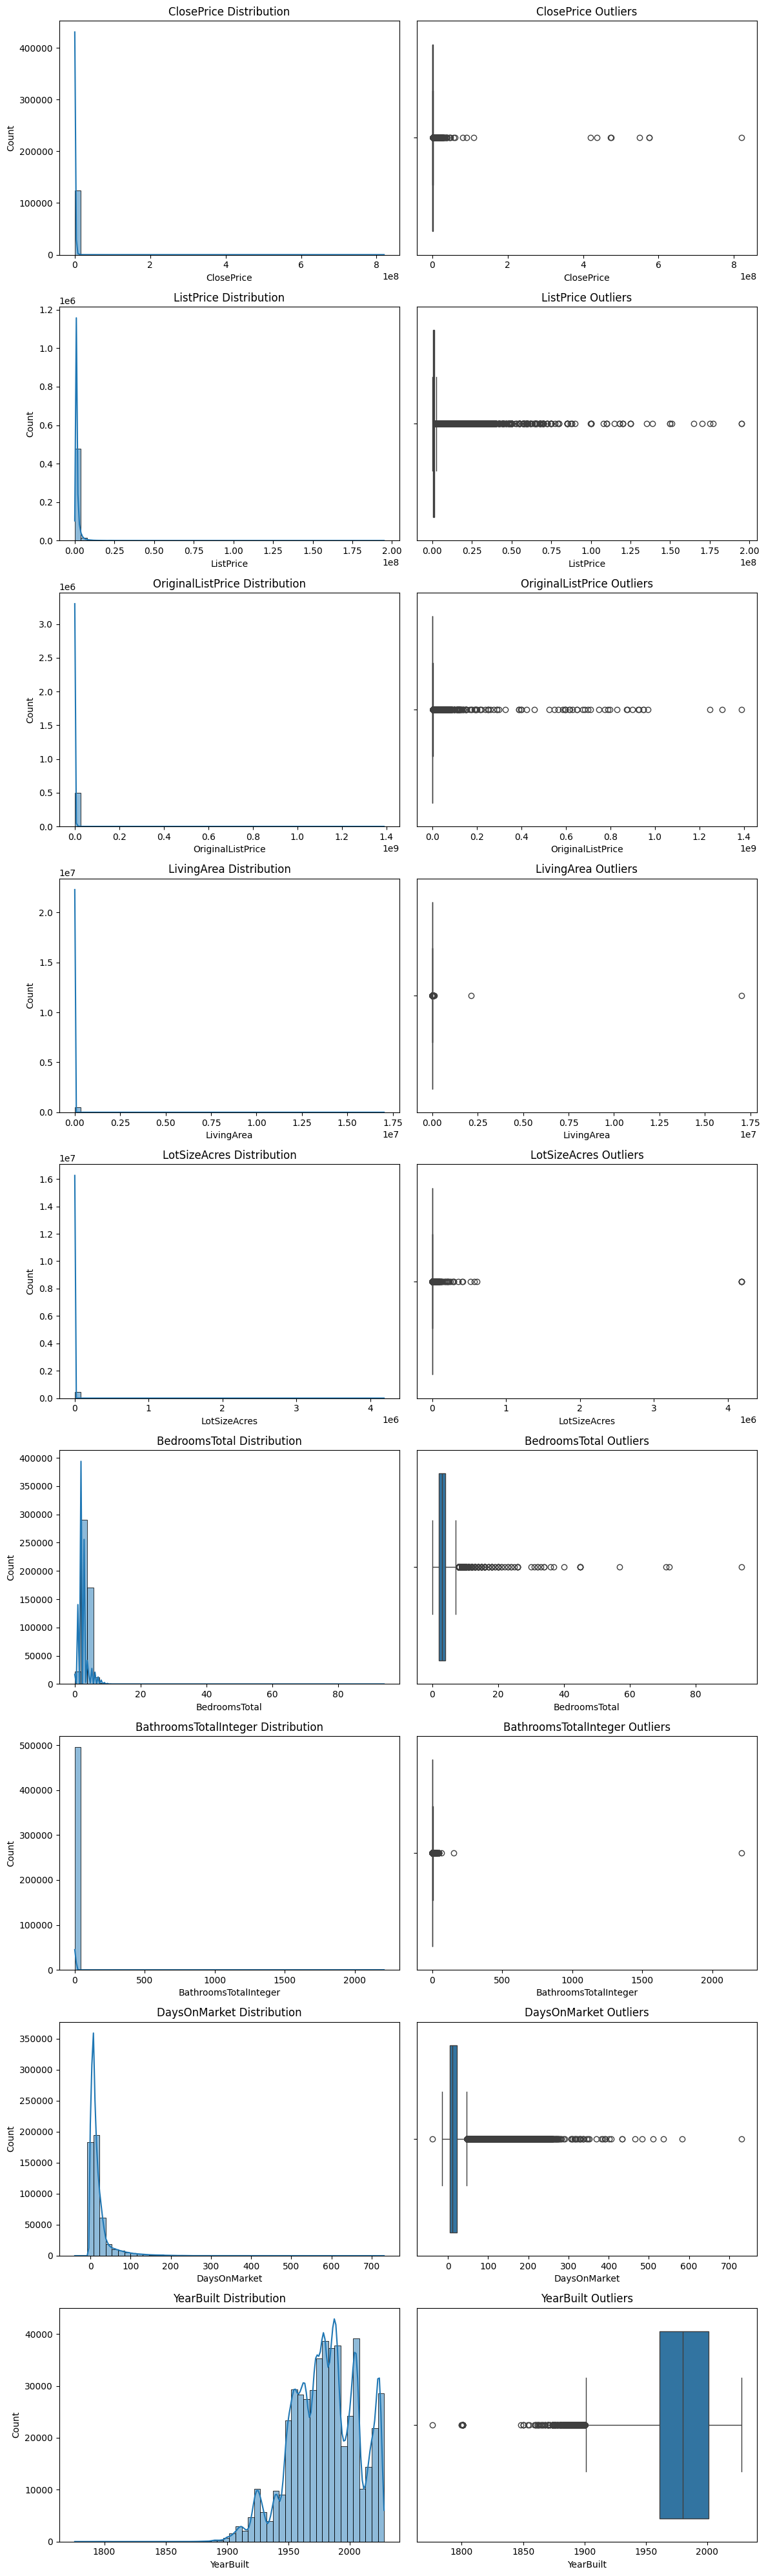

In [93]:
# Graphs
fig, axes = plt.subplots(nrows=9, ncols=2, figsize=(12,40))

for i, col in enumerate(core_numeric):
    # Histogram
    sns.histplot(listing_df[col],bins=50,kde=True, ax=axes[i,0])
    axes[i,0].set_title(f'{col} Distribution')
    
    # Boxplot
    sns.boxplot(x=listing_df[col], ax=axes[i,1])
    axes[i,1].set_title(f'{col} Outliers')
plt.tight_layout()
plt.show()

### Mortgage Rate Enrichment

In [94]:
import pandas as pd

# 1. Fetch mortgage rate data directly from the URL (Handbook Method)
# FIX: Change 'DATE' to 'observation_date'
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url, parse_dates=['observation_date'])

# 2. Rename columns so 'observation_date' becomes 'date' for the pipeline
mortgage.columns = ['date', 'rate_30yr_fixed']

# 3. Resample weekly rates to monthly averages
mortgage['year_month'] = mortgage['date'].dt.to_period('M')
mortgage_monthly = mortgage.groupby('year_month')['rate_30yr_fixed'].mean().reset_index()

# 4. Create a matching year_month key on the MLS dataset using ListingContractDate
listing_df['year_month'] = pd.to_datetime(listing_df['ListingContractDate']).dt.to_period('M')

# 5. Merge the dataframes together
listing_with_rates_df = listing_df.merge(mortgage_monthly, on='year_month', how='left')

# 6. Check for missing values and preview the success
print(f"Null mortgage rates: {listing_with_rates_df['rate_30yr_fixed'].isnull().sum()}")
print("\nPreview of the enriched dataset:")
print(listing_with_rates_df[['ListingContractDate', 'year_month', 'ListPrice', 'rate_30yr_fixed']].head())

Null mortgage rates: 0

Preview of the enriched dataset:
  ListingContractDate year_month  ListPrice  rate_30yr_fixed
0          2026-02-09    2026-02  1395000.0           6.0475
1          2026-02-21    2026-02   599000.0           6.0475
2          2026-02-18    2026-02  1200000.0           6.0475
3          2026-02-27    2026-02  4590000.0           6.0475
4          2026-02-26    2026-02   878800.0           6.0475


In [ ]:
# Export to csv
# listings_with_rates.to_csv('CRMLS_Listing_With_Rates.csv', index=False)

## Data Cleaning and Preparation

In [95]:
# Convert data fields to datetime format
date_cols = ['CloseDate','ListingContractDate','PurchaseContractDate','ContractStatusChangeDate']
for col in date_cols:
    if col in listing_with_rates_df.columns:
        listing_with_rates_df[col]= pd.to_datetime(listing_with_rates_df[col])


In [ ]:
# Check for duplicates
listing_with_rates_df[listing_with_rates_df.duplicated(subset='ListingKey')]
listing_with_rates_df = listing_with_rates_df.drop_duplicates(subset=['ListingKey'], keep='last') # Keep the most recent property with the listing key

In [97]:
# Drop duplicate columns
listing_with_rates_df = listing_with_rates_df.drop(columns=[col for col in listing_with_rates_df.columns if col.endswith('.1')])

In [98]:
# FIX: Drop rows if missing critical value (ListPrice instead of ClosePrice)
must_columns = ['ListingKey', 'ListPrice', 'City']
listing_with_rates_df = listing_with_rates_df.dropna(subset=must_columns)

In [99]:
# Fill in missing counts with '0'
zero_fill_cols = ['GarageSpaces', 'ParkingTotal', 'FireplacesTotal']

for col in zero_fill_cols:
    if col in listing_with_rates_df.columns:
        listing_with_rates_df[col] = listing_with_rates_df[col].fillna(0)

# Fill in missing Yes/No features with 'No'
fill_no_cols = ['PoolPrivateYN', 'ViewYN', 'CoolingYN', 'HeatingYN']
for col in fill_no_cols:
    if col in listing_with_rates_df.columns:
        listing_with_rates_df[col] = listing_with_rates_df[col].fillna(False)

# Fill in missing categorical data with "Unknown"
cat_fill_cols = ['ArchitectureStyle', 'Heating', 'Cooling', 'WaterSource']
for col in cat_fill_cols:
    if col in listing_with_rates_df.columns:
        listing_with_rates_df[col] = listing_with_rates_df[col].fillna('Unknown')

# Fill in missing numerical values
num_fill_cols = ['LotSizeArea', 'YearBuilt']
for col in num_fill_cols:
    if col in listing_with_rates_df.columns:
        col_median = listing_with_rates_df[col].median()
        listing_with_rates_df[col] = listing_with_rates_df[col].fillna(col_median)


In [100]:
# Drop missing Living Area
listing_with_rates_df = listing_with_rates_df.dropna(subset='LivingArea')
# Filter out where Living Area is less than 0
listing_with_rates_df = listing_with_rates_df[listing_with_rates_df['LivingArea'] > 0]

In [101]:
# FIX: Remove rows with invalid numeric values
listing_with_rates_df = listing_with_rates_df[
    (listing_with_rates_df['ListPrice'] > 0) & 
    (listing_with_rates_df['LivingArea'] > 0) & 
    (listing_with_rates_df['DaysOnMarket'] >= 0) & 
    (listing_with_rates_df['BedroomsTotal'] >= 0) & 
    (listing_with_rates_df['BathroomsTotalInteger'] >= 0)
]

In [102]:
# A listing cannot go under contract before it is listed!
invalid_contracts = (listing_with_rates_df['ListingContractDate'] > listing_with_rates_df['PurchaseContractDate']) & listing_with_rates_df['PurchaseContractDate'].notna()

listing_with_rates_df['contract_before_listing_flag'] = invalid_contracts
listing_with_rates_df['negative_timeline_flag'] = listing_with_rates_df['DaysOnMarket'] < 0

print(f"Contract Date Errors: {listing_with_rates_df['contract_before_listing_flag'].sum()}")
print(f"Negative Timeline Errors: {listing_with_rates_df['negative_timeline_flag'].sum()}")

Contract Date Errors: 242
Negative Timeline Errors: 0


In [ ]:
# Geographic Data Checks
print(f"Number of rows before cleaning: {listing_with_rates_df.shape[0]}")
listing_with_rates_df['missing_coords'] = listing_with_rates_df['Latitude'].isnull() | listing_with_rates_df['Longitude'].isnull()
listing_with_rates_df['sentinel_coords'] = (listing_with_rates_df['Latitude'] == 0) | (listing_with_rates_df['Longitude'] == 0)
listing_with_rates_df['cal_coords'] = listing_with_rates_df['Longitude'] > 0

# Verify row numbers
print(f'Number of rows after cleaning: {listing_with_rates_df.shape[0]}')

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,...,ListAgentEmail,BuyerAgencyCompensationType,BuyerAgencyCompensation,year_month,rate_30yr_fixed,contract_before_listing_flag,negative_timeline_flag,missing_coords,sentinel_coords,cal_coords
0,1395000.0,1156886900,NaT,NaN,David,Dacosta,33.115668,-117.233300,6374 Paseo Aspada Street,Residential,...,NaN,NaN,NaN,2026-02,6.0475,False,False,False,False,False
1,599000.0,1156886097,NaT,NaN,Ray,Fraser,32.614331,-116.961123,2137 Stellar Way 3,Residential,...,NaN,NaN,NaN,2026-02,6.0475,False,False,False,False,False
2,1200000.0,1156884861,2026-04-06,1100000.0,Dave,Pedneault,33.851095,-118.043704,7631 Cory Circle,Residential,...,NaN,NaN,NaN,2026-02,6.0475,False,False,False,False,False
3,4590000.0,1156882650,NaT,NaN,Karen,Davidson,34.297242,-119.202128,1038 Scenic Way Drive,Residential,...,NaN,NaN,NaN,2026-02,6.0475,False,False,False,False,False
4,878800.0,1156880439,NaT,NaN,Jenny,Chung,34.015334,-117.869695,3445 Gauntlet Drive,Residential,...,NaN,NaN,NaN,2026-02,6.0475,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495513,929900.0,1138313758,NaT,NaN,Melissa,Hazlett,32.616974,-116.991162,1495 Pershing Road,Residential,...,mhazlett@pcc-heritage.com,NaN,NaN,2026-01,6.1025,False,False,False,False,False
495514,2480000.0,1137678822,2026-02-19,2300000.0,Michelle,Serafini,32.816639,-117.234578,2252 Soledad Rancho Road,Residential,...,michelle.serafini@compass.com,NaN,NaN,2026-01,6.1025,False,False,False,False,False
495515,425000.0,1134562727,NaT,NaN,Mike,Aqrawi,32.800275,-116.956766,505 E Madison Ave 70,Residential,...,Mike@sandiegohomesrealty.com,NaN,NaN,2026-01,6.1025,False,False,False,False,False
495516,790000.0,1114826339,NaT,NaN,Gabriel,Mendez,32.678852,-117.038393,7089 wattle drive,Residential,...,gabe@gabemendez.realtor,NaN,NaN,2026-01,6.1025,False,False,False,False,False


In [ ]:
# Filter out Living Area for reasonable values
listing_with_rates_df = listing_with_rates_df[listing_with_rates_df['LivingArea'].isna() | (listing_with_rates_df['LivingArea'] > 0)]

# Filter bad coordinates (longitude and latitude)
listing_with_rates_df = listing_with_rates_df[listing_with_rates_df['Latitude'].isna() | listing_with_rates_df['Longitude'].between(-124,-114)]

# Filter out DaysOnMarket
listing_with_rates_df = listing_with_rates_df[listing_with_rates_df['DaysOnMarket'].isna() | (listing_with_rates_df['DaysOnMarket']>= 0)]

In [ ]:
# Export to csv
# listing_with_rates_df.to_csv('CRMLS_Listing_With_Rates_Cleaned.csv', index=False)

## Feature Engineering 
Some Week 6 metrics require closed transactions (`CloseDate`, `ClosePrice`). Because the listings dataset includes active and pending records, those sold-only features are not engineered here. Instead, this notebook focuses on listing-stage metrics derived from `ListingContractDate`, `ListPrice`, `LivingArea`, and `DaysOnMarket`.

In [ ]:
# Get year, month, yrmo from 'ListingContractDate'
listing_with_rates_df['Year'] = listing_with_rates_df['ListingContractDate'].dt.year
listing_with_rates_df['Month'] = listing_with_rates_df['ListingContractDate'].dt.month
listing_with_rates_df['YrMo'] = listing_with_rates_df['ListingContractDate'].dt.to_period('M').astype(str)
listing_with_rates_df['ListPricePerSqFt'] = listing_with_rates_df['ListPrice'] / listing_with_rates_df['LivingArea']



In [ ]:
# Export to csv
listing_with_rates_df.to_csv('CRMLS_Listing_With_Rates_Engineered.csv', index=False)